In [3]:
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd


def load_data(path):
    # try reading TXT with automatic delimiter detection
    df = pd.read_csv(path, sep=None, engine="python")

    # standard cleaning for column types
    if 'TransactionMonth' in df.columns:
        df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

    return df

In [ ]:
def summary_stats(df, numeric_cols):
    return df[numeric_cols].describe().T

In [ ]:
def basic_plots(df, outdir):
    # 1) Loss ratio by Province (bar)
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
    prov = df.groupby('Province')[
        'LossRatio'].mean().sort_values(ascending=False)
    prov.plot(kind='bar', figsize=(10, 6))
    plt.title('Average Loss Ratio by Province')
    plt.tight_layout()
    plt.savefig(f"{outdir}/lossratio_by_province.png")
    plt.clf()

    # 2) TotalClaims distribution (box)
    plt.figure(figsize=(8, 6))
    df.boxplot(column='TotalClaims')
    plt.title('TotalClaims Boxplot')
    plt.savefig(f"{outdir}/totalclaims_boxplot.png")
    plt.clf()

    # 3) Premium vs Claims scatter (sample)
    sample = df.sample(frac=0.05, random_state=42)
    plt.figure(figsize=(8, 6))
    plt.scatter(sample['TotalPremium'], sample['TotalClaims'], alpha=0.3)
    plt.xlabel('TotalPremium')
    plt.ylabel('TotalClaims')
    plt.title('Premium vs Claims (sample)')
    plt.tight_layout()
    plt.savefig(f"{outdir}/premium_vs_claims_scatter.png")
    plt.clf()

In [ ]:
def load_data(path):
    # auto-detect delimiter for TXT
    return pd.read_csv(path, sep=None, engine="python")

In [12]:
def summary_stats(df, cols):
    return df[cols].describe()

In [ ]:
import sys

In [ ]:
def load_data(path):
    """
    Loads the TXT file with '|' delimiter
    """
    df = pd.read_csv(path, sep='|')

    # convert TransactionMonth to datetime
    if 'TransactionMonth' in df.columns:
        df['TransactionMonth'] = pd.to_datetime(
            df['TransactionMonth'], errors='coerce')

    return df

In [ ]:
def summary_stats(df, cols):
    """
    Returns descriptive statistics for numeric columns
    """
    # Only keep columns that exist and are numeric
    numeric_cols = [
        c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        print("No numeric columns found for summary")
        return None
    return df[numeric_cols].describe()

In [ ]:
df = load_data("../data/MachineLearningRating_v3.txt")

# -----------------------------
# Define numeric columns
# -----------------------------
numeric_cols = ['TotalPremium', 'TotalClaims',
                'CalculatedPremiumPerTerm', 'CustomValueEstimate']

# -----------------------------
# Compute summary stats
# -----------------------------
summary = summary_stats(df, numeric_cols)

# Display result
summary

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2692\471706274.py:5: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep='|')


,TotalPremium,TotalClaims,CalculatedPremiumPerTerm,CustomValueEstimate
count,1.000098e+06,1.000098e+06,1.000098e+06,2.204560e+05
mean,6.190550e+01,6.486119e+01,1.178757e+02,2.255311e+05
std,2.302845e+02,2.384075e+03,3.997017e+02,5.645157e+05
min,-7.825768e+02,-1.200241e+04,0.000000e+00,2.000000e+04
25%,0.000000e+00,0.000000e+00,3.224800e+00,1.350000e+05
50%,2.178333e+00,0.000000e+00,8.436900e+00,2.200000e+05
75%,2.192982e+01,0.000000e+00,9.000000e+01,2.800000e+05
max,6.528260e+04,3.930921e+05,7.442217e+04,2.655000e+07


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2692\1175729203.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prov.index, y=prov.values, palette="viridis")


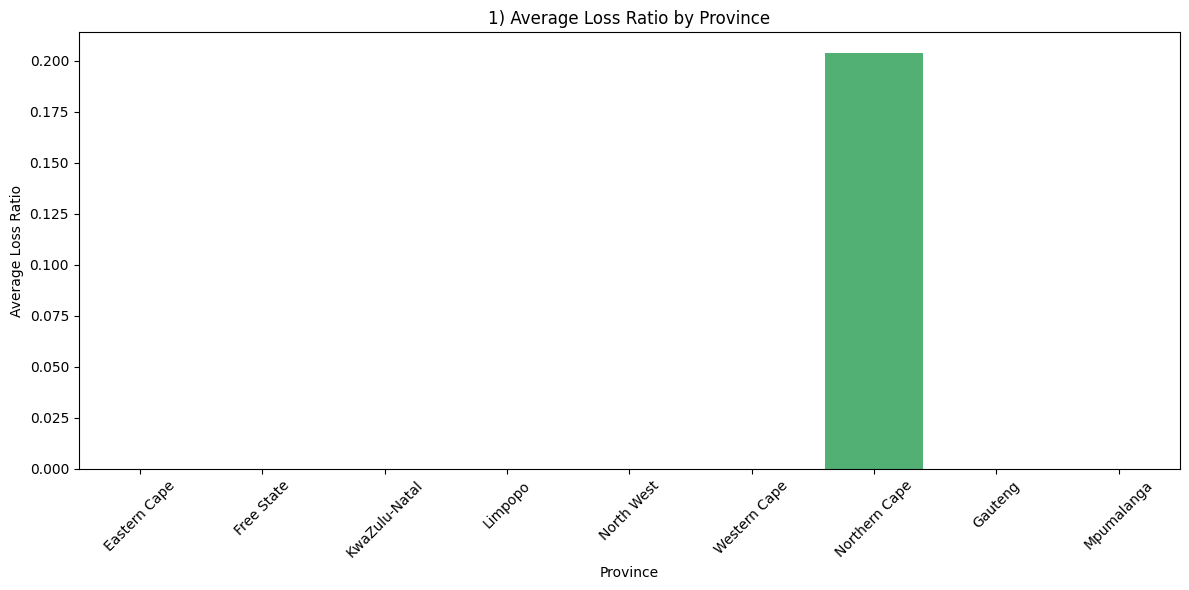

<Figure size 640x480 with 0 Axes>

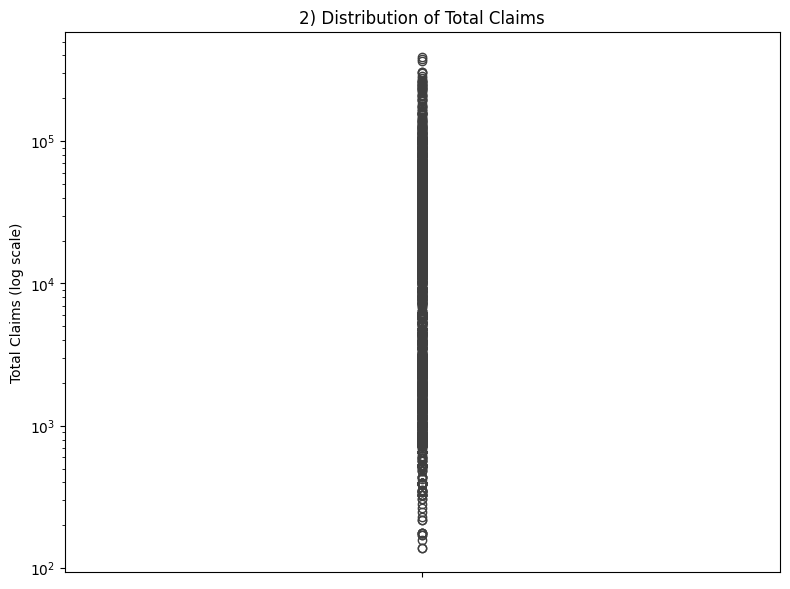

<Figure size 640x480 with 0 Axes>

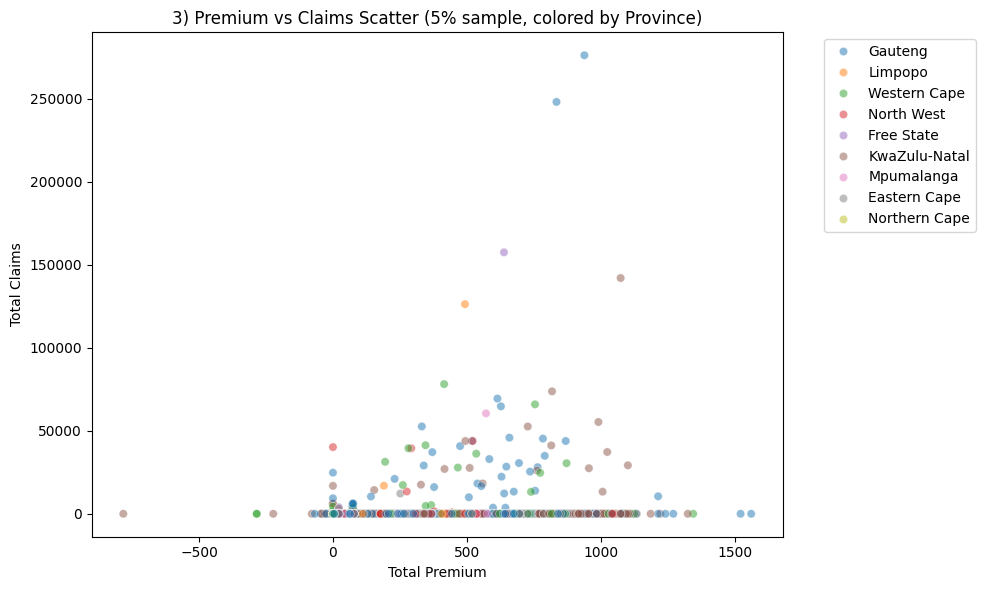

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------
# Function to create plots
# -----------------------------


def basic_plots(df, outdir="reports/plots"):
    """
    Produces 3 creative plots:
    1) Average Loss Ratio by Province
    2) TotalClaims Boxplot (log scale)
    3) Premium vs Claims Scatter by sample of PostalCodes
    """
    # create output directory if not exists
    os.makedirs(outdir, exist_ok=True)

    # ----------------------------------------
    # 1) Average Loss Ratio by Province (bar)
    # ----------------------------------------
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
    prov = df.groupby('Province')[
        'LossRatio'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=prov.index, y=prov.values, palette="viridis")
    plt.xticks(rotation=45)
    plt.ylabel("Average Loss Ratio")
    plt.title("1) Average Loss Ratio by Province")
    plt.tight_layout()
    plt.savefig(f"{outdir}/lossratio_by_province.png")
    plt.show()
    plt.clf()

    # ----------------------------------------
    # 2) TotalClaims Boxplot (log scale)
    # ----------------------------------------
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df['TotalClaims'])
    plt.yscale("log")  # handle outliers
    plt.ylabel("Total Claims (log scale)")
    plt.title("2) Distribution of Total Claims")
    plt.tight_layout()
    plt.savefig(f"{outdir}/totalclaims_boxplot.png")
    plt.show()
    plt.clf()

    # ----------------------------------------
    # 3) Premium vs Claims scatter (sampled)
    # ----------------------------------------
    sample = df.sample(frac=0.05, random_state=42)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='TotalPremium', y='TotalClaims', hue='Province',
                    data=sample, alpha=0.5, palette="tab10")
    plt.xlabel("Total Premium")
    plt.ylabel("Total Claims")
    plt.title("3) Premium vs Claims Scatter (5% sample, colored by Province)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{outdir}/premium_vs_claims_scatter.png")
    plt.show()
    plt.clf()


# -----------------------------
# Run plots
# -----------------------------
basic_plots(df)